# Rezultati i evaluacija - Tipologija zgrada Novog Sada

Prikaz dobijene tipologije: veličine i profili tipova, interpretacija, izbor broja klastera, validacija i mape.

Pokrenuti nakon celog pipeline-a (`main.py`). Potrebni su `data/features_building.parquet`, `data/features_building_clustered.parquet` i slike u `figures/`, tabele u `results/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from scripts import config
plt.rcParams['figure.figsize'] = (8, 4)

feat = gpd.read_parquet(os.path.join(config.DATA, 'features_building.parquet')).drop(columns='geometry')
clab = gpd.read_parquet(os.path.join(config.DATA, 'features_building_clustered.parquet'))[['bid', 'cluster']]
df = feat.merge(clab, on='bid')
EXCLUDE = ('bid', 'class', 'subtype', 'cluster')
FEAT = [c for c in df.columns if c not in EXCLUDE + config.REDUNDANT_FEATURES and df[c].dtype.kind in 'fi']
print(len(df), 'zgrada |', df['cluster'].nunique(), 'klastera |', len(FEAT), 'atributa za grupisanje')

103873 zgrada | 4 klastera | 17 atributa za grupisanje


## Veličine klastera

cluster
0    33.2 %
1    41.7 %
2    20.8 %
3     4.3 %
Name: count, dtype: object


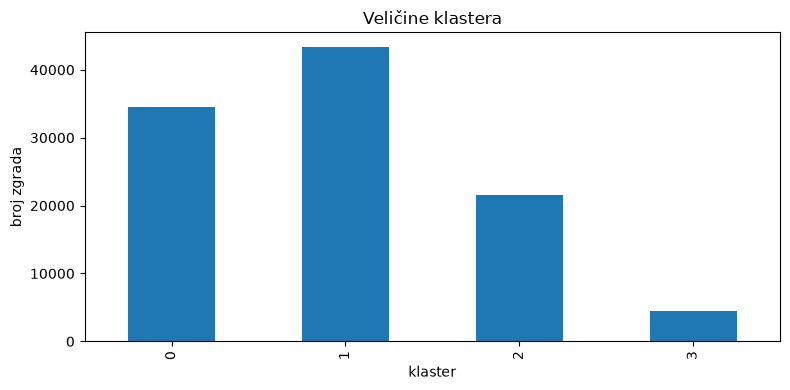

In [2]:
sz = df['cluster'].value_counts().sort_index()
print((sz / sz.sum() * 100).round(1).astype(str) + ' %')
ax = sz.plot(kind='bar'); ax.set_xlabel('klaster'); ax.set_ylabel('broj zgrada')
ax.set_title('Veličine klastera'); plt.tight_layout(); plt.show()

## Profili tipova

Standardizovane sredine atributa po klasteru (z-skor po atributu). Crveno = iznad proseka, plavo = ispod, pa se vidi šta definiše svaki tip.

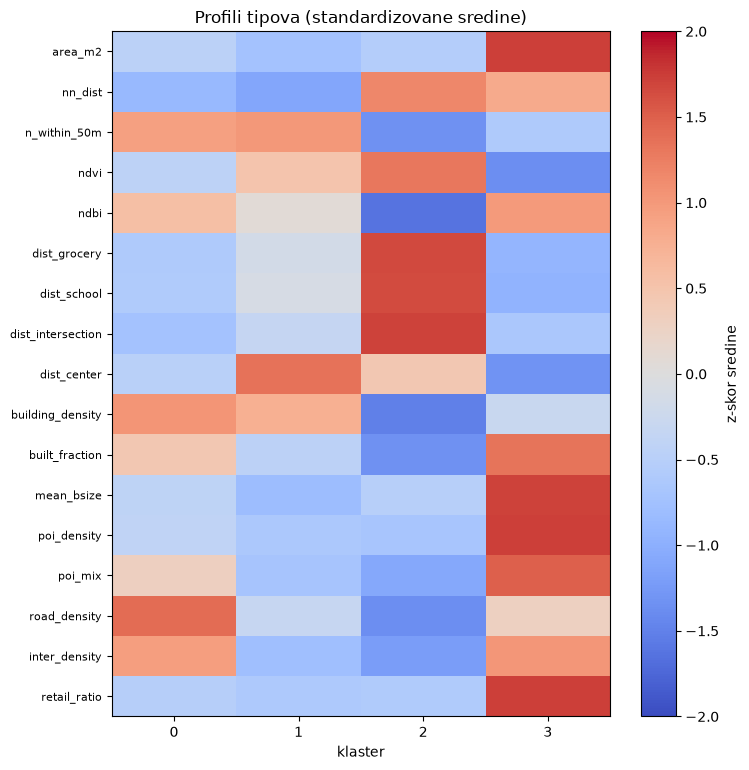

,area_m2,nn_dist,n_within_50m,ndvi,ndbi,dist_grocery,dist_school,dist_intersection,dist_center,building_density,built_fraction,mean_bsize,poi_density,poi_mix,road_density,inter_density,retail_ratio
cluster,,,,,,,,,,,,,,,,,
0,180.830002,15.15,13.62,0.36,0.01,244.039993,446.410004,68.760002,4265.370117,1385.560059,0.23,187.410004,45.070000,4.28,27052.800781,69.930000,0.02
1,111.570000,13.82,13.87,0.44,-0.01,431.119995,744.159973,99.610001,10756.990234,1277.670044,0.14,115.370003,10.560000,1.61,16636.609375,26.740000,0.00
2,161.259995,26.42,5.45,0.51,-0.10,1196.449951,1821.880005,257.720001,7511.279785,371.649994,0.05,170.130005,4.210000,0.58,10265.120117,15.620000,0.01
3,779.539978,24.48,8.11,0.27,0.03,108.690002,226.830002,74.610001,1229.160034,853.830017,0.32,584.989990,356.230011,7.44,20304.089844,71.720001,0.31


In [3]:
prof = df.groupby('cluster')[FEAT].mean()
profz = ((prof - prof.mean()) / prof.std(ddof=0)).fillna(0)
plt.figure(figsize=(1.4 * len(prof) + 2, 0.4 * len(FEAT) + 1))
plt.imshow(profz.T, cmap='coolwarm', vmin=-2, vmax=2, aspect='auto')
plt.xticks(range(len(prof.index)), prof.index)
plt.yticks(range(len(FEAT)), FEAT, fontsize=8)
plt.colorbar(label='z-skor sredine'); plt.xlabel('klaster')
plt.title('Profili tipova (standardizovane sredine)'); plt.tight_layout(); plt.show()
prof.round(2)

### Interpretacija tipova (k=4)

Kanonska tipologija ima **4 tipa** (imena/boje u `maps.py` → `LABELS[4]`, usklađena sa profilima iznad):
- **0 - Urbano stambeno:** velika gustina zgrada, blizu centra, dobro opsluženo sadržajima, pretežno stambeno.
- **1 - Prigradsko/seosko stambeno:** gusto ali sitno ziđe, daleko od centra, malo sadržaja (jezgra prigradskih sela).
- **2 - Ruralno/retko:** najniža gustina, najveći `ndvi`, najveća rastojanja do sadržaja (rasuto / poljoprivredno).
- **3 - Centralno mešovito jezgro:** najveće zgrade, najviša gustina i raznovrsnost POI, visok `retail_ratio`, najbliže centru. Napomena: tip je definisan veličinom objekata i zasićenošću okoline sadržajima, pa pored istorijskog centra obuhvata i krupne komercijalno-industrijske objekte severnih zona.

Napomena: numeracija klastera je deterministička (fiksni `random_state`), a mapiranje `cluster → ime/boja` stoji u `maps.py` (`LABELS`). Pored k=4 rade se i makro-podela **k=2** (Urbano/izgrađeno vs Ruralno/rasuto) i prelazna **k=3**.

## Izbor broja klastera (k)

In [ ]:
for name in ['dendrogram.png', 'k_selection.png']:
    p = os.path.join(config.FIGURES, name)
    if os.path.exists(p):
        plt.figure(figsize=(11, 4)); plt.imshow(plt.imread(p)); plt.axis('off')
        plt.title(name); plt.show()
    else:
        print('nedostaje', name, '- pokreni k_selection.py')

Broj klastera biran je iz strukture **Ward dendrograma**, uz proveru **stabilnosti na 20 nezavisnih uzoraka** (`results/k_selection_stability.csv`):
- **najveći skok → k=2** (15/20, 75%) = robustna makro-podela (izgrađeno/gusto vs rasuto);
- **drugi skok → k=3 modalno** (9/20), zatim **k=4 i k=2 po 5/20** (k=7 jednom, šum uzorkovanja) - finiji rez je dvosmislen između k=3 i k=4; **k=5 se ne pojavljuje (0/20)** i odbačen je;
- **k=4** je usvojen kao **operativna tipologija** (modelarska odluka: jedina granularnost koja izdvaja centralno mešovito jezgro), uz k=3 kao ravnopravnu grublju alternativu.

Elbow i silueta su prikazani samo uporedno; siluetu ne koristimo za poređenje između različitih k (nije smisleno uporediva), nego opisno na izabranom k.

In [ ]:
# Stabilnost izbora k na 20 nezavisnih uzoraka (Ward na uzorku od 30k)
sp = os.path.join(config.RESULTS, 'k_selection_stability.csv')
if os.path.exists(sp):
    st = pd.read_csv(sp)
    print('najveći skok (k):', dict(st['k_largest_gap'].value_counts().sort_index()))
    print('drugi skok  (k):', dict(st['k_second_gap'].value_counts().sort_index()))
else:
    print('nedostaje k_selection_stability.csv - pokreni k_selection.py')

## Validacija

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

X = df[FEAT].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
Z = PCA(n_components=0.95, random_state=0).fit_transform(StandardScaler().fit_transform(X))
# isti podskup za siluetu kao u comparisons.py (30k pa 10k iz istog generatora),
# da se broj poklapa sa ispisom comparisons.py
rng = np.random.default_rng(0)
_ = rng.choice(len(Z), min(config.DENDROGRAM_SAMPLE, len(Z)), replace=False)
idx = rng.choice(len(Z), min(10000, len(Z)), replace=False)
print('silueta na izabranom k (uzorak, opisno):', round(silhouette_score(Z[idx], df['cluster'].values[idx]), 3))

if 'subtype' in df.columns:
    print('\nklaster x Overture subtype (spoljna validacija):')
    print(pd.crosstab(df['cluster'], df['subtype'].fillna('None')).to_string())

## Mape tipova

k=4 (operativna tipologija): puna mapa i uža (centar). Plus **k=2** makro-podela i prelazna **k=3**.

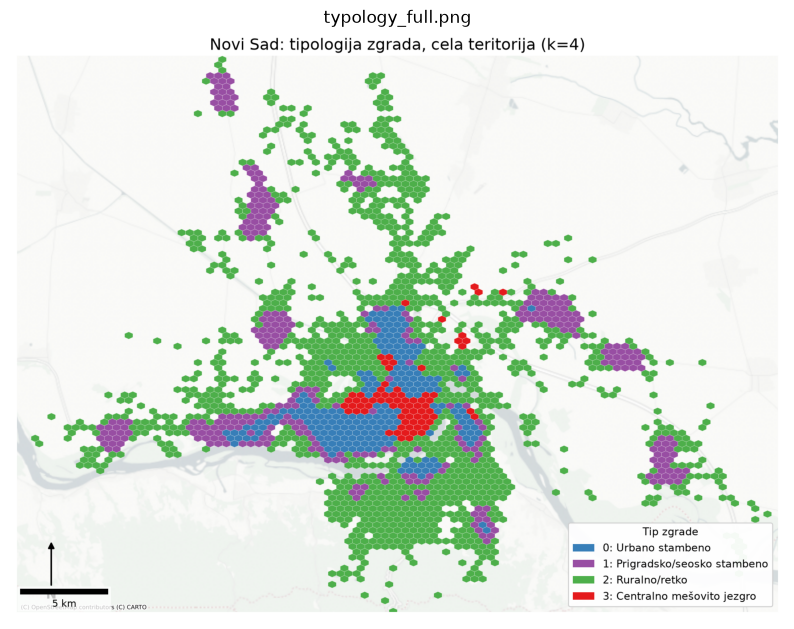

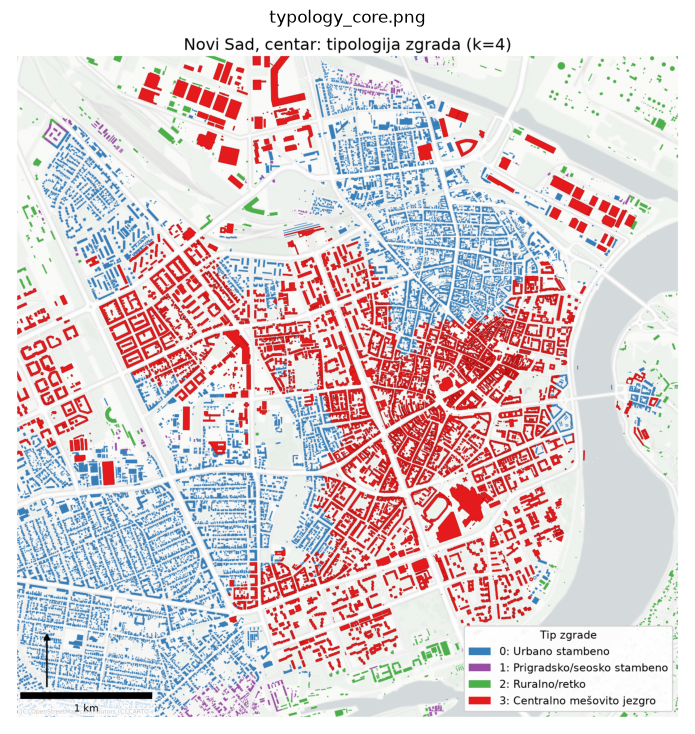

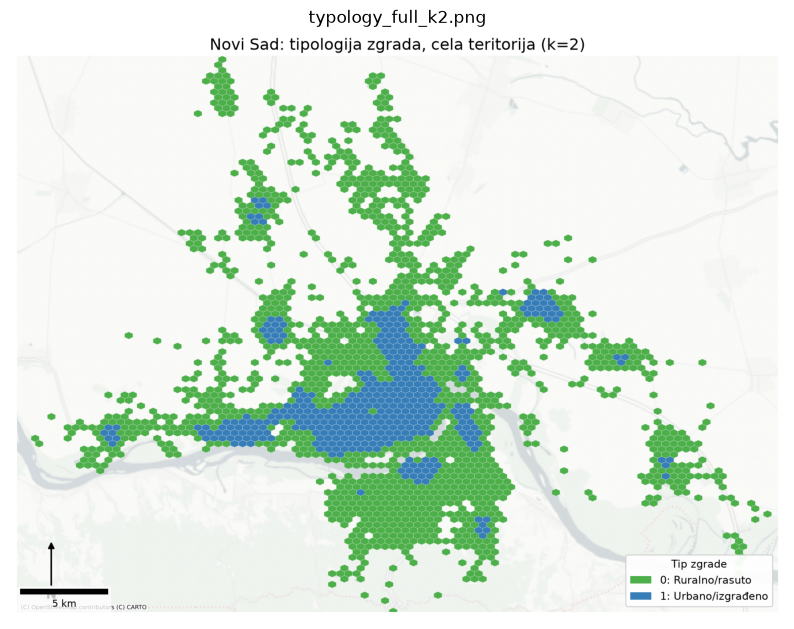

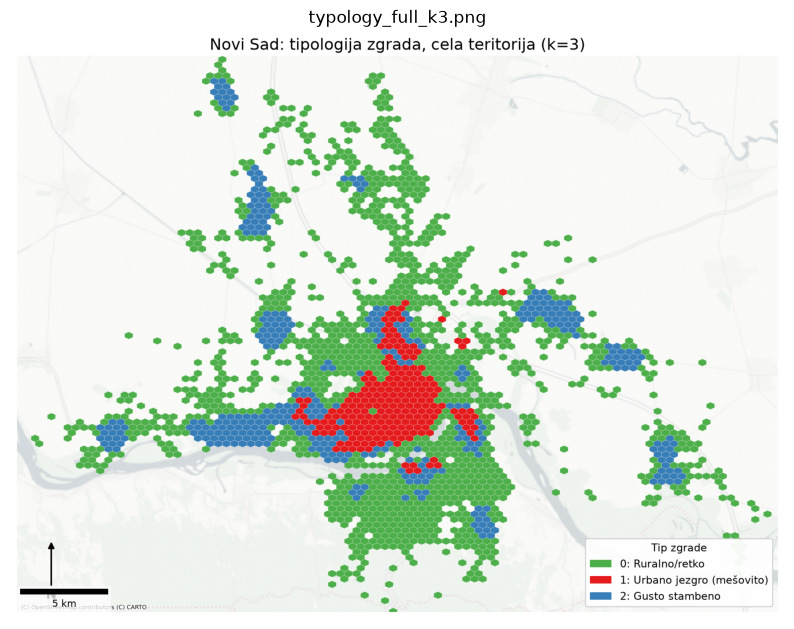

In [7]:
for name in ['typology_full.png', 'typology_core.png', 'typology_full_k2.png', 'typology_full_k3.png']:
    p = os.path.join(config.FIGURES, name)
    if os.path.exists(p):
        plt.figure(figsize=(10, 9)); plt.imshow(plt.imread(p)); plt.axis('off')
        plt.title(name); plt.show()